In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
from collections import Counter
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'


In [20]:
 
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'
 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = ['IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4',
               'DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean'] # specify models to remove
 
metadata_file = 'Metadata.txt'
# Generate loop_info DataFrame

In [21]:
def get_model(string,exp):
    return string.split('/')[-1].split('AIS_')[-1].split('_'+str(exp))[0]

In [22]:
models=[]
paths =[]
exps =[]
for exp in expnames:
    lst = glob.glob(pth_helene+f'{exp}/shelfmelt/*.nc')
    lst.sort()

    for name in lst:
        model = get_model(name,exp)
        if model in removeFileID:
            continue
        else:
            models.append(model)
            paths.append(name)
            exps.append(exp)
df = pd.DataFrame({ 'Experiment': exps,'Model': models, 'Path': paths}) 
for i in range(1,19):
    df['sector_'+str(i)]=0
df['AIS']=0
for i in range (df.shape[0]):
    pth_way = df.iloc[i].Path
    #get shelf area
    pth_area = f'{pth_helene}/{df.iloc[i].Experiment}/iareafl/computed_iareafl_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
    pth_tf = f'{pth_imip6hack}/{df.iloc[i].Experiment}/thermalforcing/computed_thermalforcing_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
    
    # Melting
    d = xr.open_dataset(pth_way,decode_times=False )
    # Area
    d2 = xr.open_dataset(pth_area,decode_times=False )
    #thermal foring 
    d3 = xr.open_dataset(pth_tf,decode_times=False )
    
    
    tmin = np.min([d.time.size,d2.time.size,d3.time.size])
    #melting per area
    y =-1*d.shelfmelt.values[:tmin]* 365.25 * 24 * 3600/900/d2.iareafl.values[:tmin] #GT/m^3 yr
    x = d3.thermalforcing.values[:tmin]
    yais =y 
    xais =x
    slope, intercept, r_value, p_value, std_err = linregress(x[:-1], y[:-1])
    df['AIS'].iloc[i]= slope

    for j in range(1,19):
        y =-1*d['shelfmelt_sector_'+str(j)].values[:tmin]* 365.25 * 24 * 3600/900/d2['iareafl_sector_'+str(j)].values[:tmin]  #GT/m^3 yr
        x = d3['thermalforcing_sector_'+str(j)].values[:tmin]
        mnan = np.isnan(y)
        slope, intercept, r_value, p_value, std_err = linregress(x[~mnan][:-1], y[~mnan][:-1])
        
       
        df['sector_'+str(j)].iloc[i] = slope
#         if (j==1 and i ==4):
#             print(d2['iareafl_sector_'+str(j)].values[:tmin])
#             break


/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_4218/2724377455.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AIS'].iloc[i]= slope
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_4218/2724377455.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sector_'+str(j)].iloc[i] = slope
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_4218/2724377455.py:44: RuntimeWarning: invalid value encountered in divide
  y =-1*d['shelfmelt_sector_'+str(j)].values[:tmin]* 365.25 * 24 * 3600/900/d2['iareafl_sector_'+str(j)].values[:tmin]  #GT/m^3 yr


In [23]:
models=[]
paths =[]
exps =[]
for exp in expnames:
    lst = glob.glob(pth_helene+f'{exp}/shelfmelt/*.nc')
    lst.sort()

    for name in lst:
        model = get_model(name,exp)
        if model in removeFileID:
            continue
        else:
            models.append(model)
            paths.append(name)
            exps.append(exp)
df = pd.DataFrame({ 'Experiment': exps,'Model': models, 'Path': paths}) 
for i in range(1,19):
    df['sector_'+str(i)]=0
df['AIS']=0
df2 = df.copy()
for i in range (df.shape[0]):
    pth_way = df.iloc[i].Path
    #get shelf area
    pth_area = f'{pth_helene}/{df.iloc[i].Experiment}/iareafl/computed_iareafl_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
    pth_tf = f'{pth_imip6hack}/{df.iloc[i].Experiment}/thermalforcingBin/computed_thermalforcingBin_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
    
    # Melting
    d = xr.open_dataset(pth_way,decode_times=False )
    # Area
    d2 = xr.open_dataset(pth_area,decode_times=False )
    #thermal foring 
    d3 = xr.open_dataset(pth_tf,decode_times=False )
    
    
    tmin = np.min([d.time.size,d2.time.size,d3.time.size])
    #melting per area
    y =-1*d.shelfmelt.values[:tmin]* 365.25 * 24 * 3600/900/d2.iareafl.values[:tmin] #GT/m^3 yr
    x = d3.thermalforcingBin.values[:tmin]
    yais =y 
    xais =x
    slope, intercept, r_value, p_value, std_err = linregress(x[:-1], y[:-1])
    df['AIS'].iloc[i]= slope
    df2['AIS'].iloc[i]= np.nanmean(x[:-1])
    if abs(x.mean())>10:
        print('upps sth wrong with thermal forcing','sector',j,'and',df.iloc[i].Path)

    for j in range(1,19):
        y =-1*d['shelfmelt_sector_'+str(j)].values[:tmin]* 365.25 * 24 * 3600/900/d2['iareafl_sector_'+str(j)].values[:tmin]  #GT/m^3 yr
        x = d3['thermalforcingBin_sector_'+str(j)].values[:tmin]
        mnan = np.isnan(y)
        slope, intercept, r_value, p_value, std_err = linregress(x[~mnan][:-1], y[~mnan][:-1])
        
       
        df['sector_'+str(j)].iloc[i] = slope
        df2['sector_'+str(j)].iloc[i] = np.nanmean(x[~mnan][:-1])
        
        if abs(x.mean())>10:
            print('upps sth wrong with thermal forcing','sector',j,'and', df.iloc[i].Path)

#         if (j==1 and i ==4):
#             print(d2['iareafl_sector_'+str(j)].values[:tmin])
#             break


/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_4218/389254665.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AIS'].iloc[i]= slope
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_4218/389254665.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['AIS'].iloc[i]= np.nanmean(x[:-1])
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_4218/389254665.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-c

In [24]:
df.to_csv('tables/linear_meltsensetivity.csv', index=False)

In [6]:
df2

,Experiment,Model,Path,sector_1,sector_2,sector_3,sector_4,sector_5,sector_6,sector_7,...,sector_10,sector_11,sector_12,sector_13,sector_14,sector_15,sector_16,sector_17,sector_18,AIS
0,expAE02,DC_ISSM,/Volumes/CrucialX8/computing/data/antarctica/i...,2.047172,1.314594,1.654792,2.147969,1.495007,0.827533,1.409043,...,2.160055,1.497850,0.877079,1.856178,1.677137,1.460386,1.081055,1.468231,3.054913,1.506075
1,expAE02,IGE_ElmerIce,/Volumes/CrucialX8/computing/data/antarctica/i...,2.153507,1.697210,1.926974,2.574601,2.538881,1.377669,1.499288,...,2.087028,2.539821,0.881691,1.679122,1.769161,1.551255,1.205744,1.475548,3.134743,1.974176
2,expAE02,ILTS_SICOPOLIS,/Volumes/CrucialX8/computing/data/antarctica/i...,2.515310,1.410775,1.857702,2.527315,1.683215,0.778718,1.318542,...,1.987251,1.653713,0.830250,1.259519,1.883747,1.560640,0.853846,1.302211,3.241202,1.486880
3,expAE02,LSCE_GRISLI2,/Volumes/CrucialX8/computing/data/antarctica/i...,1.979147,1.772083,1.665630,2.189418,2.187954,1.007504,1.378741,...,2.006548,1.703468,0.892625,1.487937,1.775444,1.589630,0.990003,1.221395,2.914391,1.807129
4,expAE02,LSCE_GRISLI,/Volumes/CrucialX8/computing/data/antarctica/i...,2.035341,1.825163,1.640070,2.499407,2.310752,1.045568,1.371353,...,2.055713,1.547376,0.789172,1.408021,1.948113,1.772640,1.013778,1.549653,2.872505,1.910248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,expAE05,VUW_PISM2,/Volumes/CrucialX8/computing/data/antarctica/i...,4.416055,4.043499,4.102168,3.177122,2.465336,3.644584,2.628536,...,2.942660,2.444331,2.075091,1.744333,2.666187,2.746410,1.443724,1.796007,2.573843,2.909515
140,expAE05,VUW_PISM2_s1,/Volumes/CrucialX8/computing/data/antarctica/i...,4.340835,4.043205,4.141006,3.157273,2.446106,3.629143,2.685682,...,2.903291,2.426570,2.202673,1.747258,2.548514,2.737280,1.422638,1.889456,2.553671,2.911526
141,expAE05,VUW_PISM2_s2,/Volumes/CrucialX8/computing/data/antarctica/i...,4.413693,4.046860,4.080370,3.233587,2.493885,3.597376,2.580942,...,2.881552,2.456229,2.131149,1.756320,2.720708,2.780103,1.445297,1.800119,2.599968,2.902306
142,expAE05,VUW_PISM2_s3,/Volumes/CrucialX8/computing/data/antarctica/i...,4.404750,4.041337,4.106788,3.106330,2.502318,3.602260,2.558306,...,2.834727,2.440152,2.208210,1.758803,2.685429,2.768506,1.415319,1.822989,2.607236,2.898053


In [13]:
df

,Experiment,Model,Path,sector_1,sector_2,sector_3,sector_4,sector_5,sector_6,sector_7,...,sector_10,sector_11,sector_12,sector_13,sector_14,sector_15,sector_16,sector_17,sector_18,AIS
0,expAE02,DC_ISSM,/Volumes/CrucialX8/computing/data/antarctica/i...,3.896319,4.988102,5.960325,11.157589,5.409729,4.367866,5.804448,...,3.956426,4.971462,2.323555,2.482972,5.111168,4.378808,1.775358,1.754730,3.575575,5.022207
1,expAE02,IGE_ElmerIce,/Volumes/CrucialX8/computing/data/antarctica/i...,2.555729,1.427926,3.171974,2.838962,2.034172,0.712886,7.703998,...,2.717118,1.713825,11.614642,2.834072,6.615948,3.664216,0.956331,1.822759,3.181793,1.593419
2,expAE02,ILTS_SICOPOLIS,/Volumes/CrucialX8/computing/data/antarctica/i...,15.079343,8.493658,13.555866,19.726565,10.342278,9.484005,9.472028,...,11.385958,9.480311,6.045699,11.204602,14.010558,11.400283,5.101377,8.756495,14.826735,11.296855
3,expAE02,LSCE_GRISLI2,/Volumes/CrucialX8/computing/data/antarctica/i...,11.354673,9.451560,11.495676,16.067899,9.657771,7.856671,8.408077,...,10.166953,8.508843,5.519214,11.540843,11.810602,9.942799,4.983624,6.128809,11.965723,10.118505
4,expAE02,LSCE_GRISLI,/Volumes/CrucialX8/computing/data/antarctica/i...,11.616899,9.841488,11.685253,18.980833,8.717947,7.299050,9.039351,...,9.897273,7.608609,4.728054,10.306819,12.786194,10.718755,4.223975,6.426368,11.233586,12.520125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,expAE05,VUW_PISM2,/Volumes/CrucialX8/computing/data/antarctica/i...,13.937180,2.698228,-0.240099,17.227986,10.456630,-0.572517,11.818546,...,-0.215784,2.385795,1.009668,2.302206,2.521786,1.476280,0.387048,0.593591,3.438220,4.099578
140,expAE05,VUW_PISM2_s1,/Volumes/CrucialX8/computing/data/antarctica/i...,18.245141,3.158705,-0.032374,16.123500,10.793800,-0.568270,12.392912,...,-0.205381,2.504742,0.883841,2.606494,2.829202,1.503098,0.497880,0.602566,3.720232,4.024197
141,expAE05,VUW_PISM2_s2,/Volumes/CrucialX8/computing/data/antarctica/i...,12.981667,2.247332,-0.225989,18.336653,10.377605,-0.479094,10.906156,...,-0.294079,2.395960,1.148032,1.970868,2.429964,1.436127,0.387992,0.587672,2.703654,4.392336
142,expAE05,VUW_PISM2_s3,/Volumes/CrucialX8/computing/data/antarctica/i...,13.905610,2.224716,-0.128250,12.640586,10.596389,-0.493276,10.406498,...,-0.233269,2.231763,1.130655,2.180096,2.475565,1.258886,0.433792,0.647359,2.470033,2.985624


In [8]:
df.sector_5.values

array([ 5.40972925,  2.03417213, 10.34227808,  9.65777059,  8.71794706,
        5.5496268 ,  5.67653106,  5.98099961,  3.80852863,  5.52023427,
        4.55587165,  3.96690147,  4.53963982,  3.66504934,  3.71877033,
        3.68086504,  3.9375225 ,  2.73865313,  6.49464581,  3.96156993,
        1.43108465,  0.30094131,  9.46025514,  4.15960885,  4.15605876,
        2.68995345, 19.72928309,  0.10116069, 18.666384  , 17.4194695 ,
       18.8798922 , 16.11393174, 17.40033063, 15.98016725, 15.46575605,
       15.82787158,  7.64242465,  2.46473017, 12.97698026, 11.71791626,
       12.09554389,  7.83147951,  6.73667372,  3.69405034,  3.95053019,
        6.76479852,  3.30784386,  3.15583178,  5.10470537,  2.79216   ,
        2.86087094,  2.79829316,  4.38926556,  2.3727735 ,  8.10379527,
        6.0651926 ,  2.19643968,  0.21880649,  9.90043339,  2.87982474,
        6.85884592,  5.7646788 , 14.02833093, 14.70896808, 13.86688448,
       14.44924736, 14.14875843,  9.82655702, 10.25468965, 10.11

In [9]:
df.sector_5.values

array([ 5.40972925,  2.03417213, 10.34227808,  9.65777059,  8.71794706,
        5.5496268 ,  5.67653106,  5.98099961,  3.80852863,  5.52023427,
        4.55587165,  3.96690147,  4.53963982,  3.66504934,  3.71877033,
        3.68086504,  3.9375225 ,  2.73865313,  6.49464581,  3.96156993,
        1.43108465,  0.30094131,  9.46025514,  4.15960885,  4.15605876,
        2.68995345, 19.72928309,  0.10116069, 18.666384  , 17.4194695 ,
       18.8798922 , 16.11393174, 17.40033063, 15.98016725, 15.46575605,
       15.82787158,  7.64242465,  2.46473017, 12.97698026, 11.71791626,
       12.09554389,  7.83147951,  6.73667372,  3.69405034,  3.95053019,
        6.76479852,  3.30784386,  3.15583178,  5.10470537,  2.79216   ,
        2.86087094,  2.79829316,  4.38926556,  2.3727735 ,  8.10379527,
        6.0651926 ,  2.19643968,  0.21880649,  9.90043339,  2.87982474,
        6.85884592,  5.7646788 , 14.02833093, 14.70896808, 13.86688448,
       14.44924736, 14.14875843,  9.82655702, 10.25468965, 10.11

nan

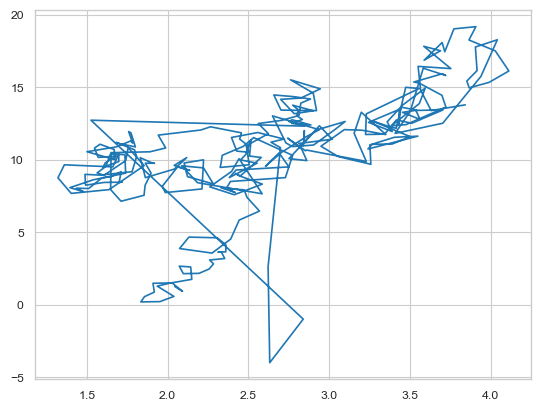

In [12]:
x[0]=np.nan
plt.plot(x[:-1],y[:-1])

slope, intercept, r_value, p_value, std_err = linregress(x, y)
plt.plot(x[:-1],slope*x[:-1]+ intercept)
slope

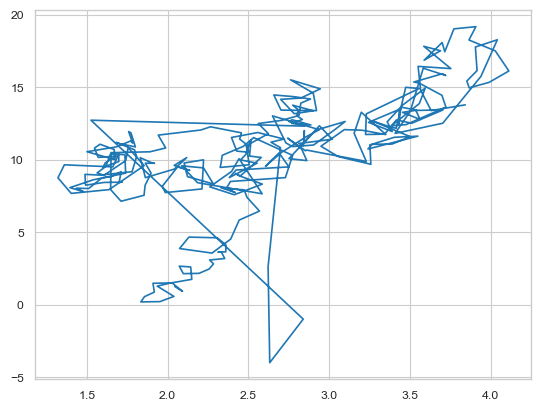

In [11]:
plt.plot(x[:-1],y)

In [28]:
df_sectors= df.copy()
df2 = df.copy()
df_sectors.drop(columns=['Experiment','Model','Path'], inplace=True)

In [59]:
df_sectors

NameError: name 'df_sectors' is not defined